In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [86]:
df = pd.read_csv("smartcart_customers.csv")

In [87]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [88]:
df.shape

(2240, 22)

In [89]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [90]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Preprocessing

##  1. Handle Missing Values

In [91]:
df["Income"]=df["Income"].fillna(df["Income"].median())

In [92]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

## 2. Feature engineering

In [93]:
# Age
df["Age"] = 2026 - df["Year_Birth"]

In [94]:
# Customer Joining Date

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst=True)
reference_data = df["Dt_Customer"].max()
df["Customer_Tenure_Days"] = (reference_data -df["Dt_Customer"]).dt.days

In [95]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days'],
      dtype='object')

In [96]:
# Total spending

df["Total_spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] +df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]


In [97]:
# Children
df["Total_children"] = df["Kidhome"] + df["Teenhome"]

In [98]:
# Education

# Undergraduate , Graduate , Postgraduate 

df["Education"]= df["Education"].replace({
    "Basic":"Undergraduate","2n Cycle":"Undergraduate",
    "Graduation":"Graduate",
    "Master":"Postgraduate","PhD":"Postgraduate"
    
})

In [100]:
# Marital Status
df['Marital_Status'].value_counts()
df["Living_with"]=df['Marital_Status'].replace({
    "Married":"Partner", "Together":"Partner",
    "Single":"Alone" ,"Divorced":"Alone",
    "Widow":"Alone","Absurd":"Alone","YOLO":"Alone"
})

## Drop Columns

In [102]:
cols = ["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols = ['MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts','MntSweetProducts','MntGoldProds']
cols_to_drop = cols + spending_cols
df_cleaned =df.drop(columns = cols_to_drop )

In [103]:
df_cleaned.shape

(2240, 15)

In [104]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_children,Living_with
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


# Outliers

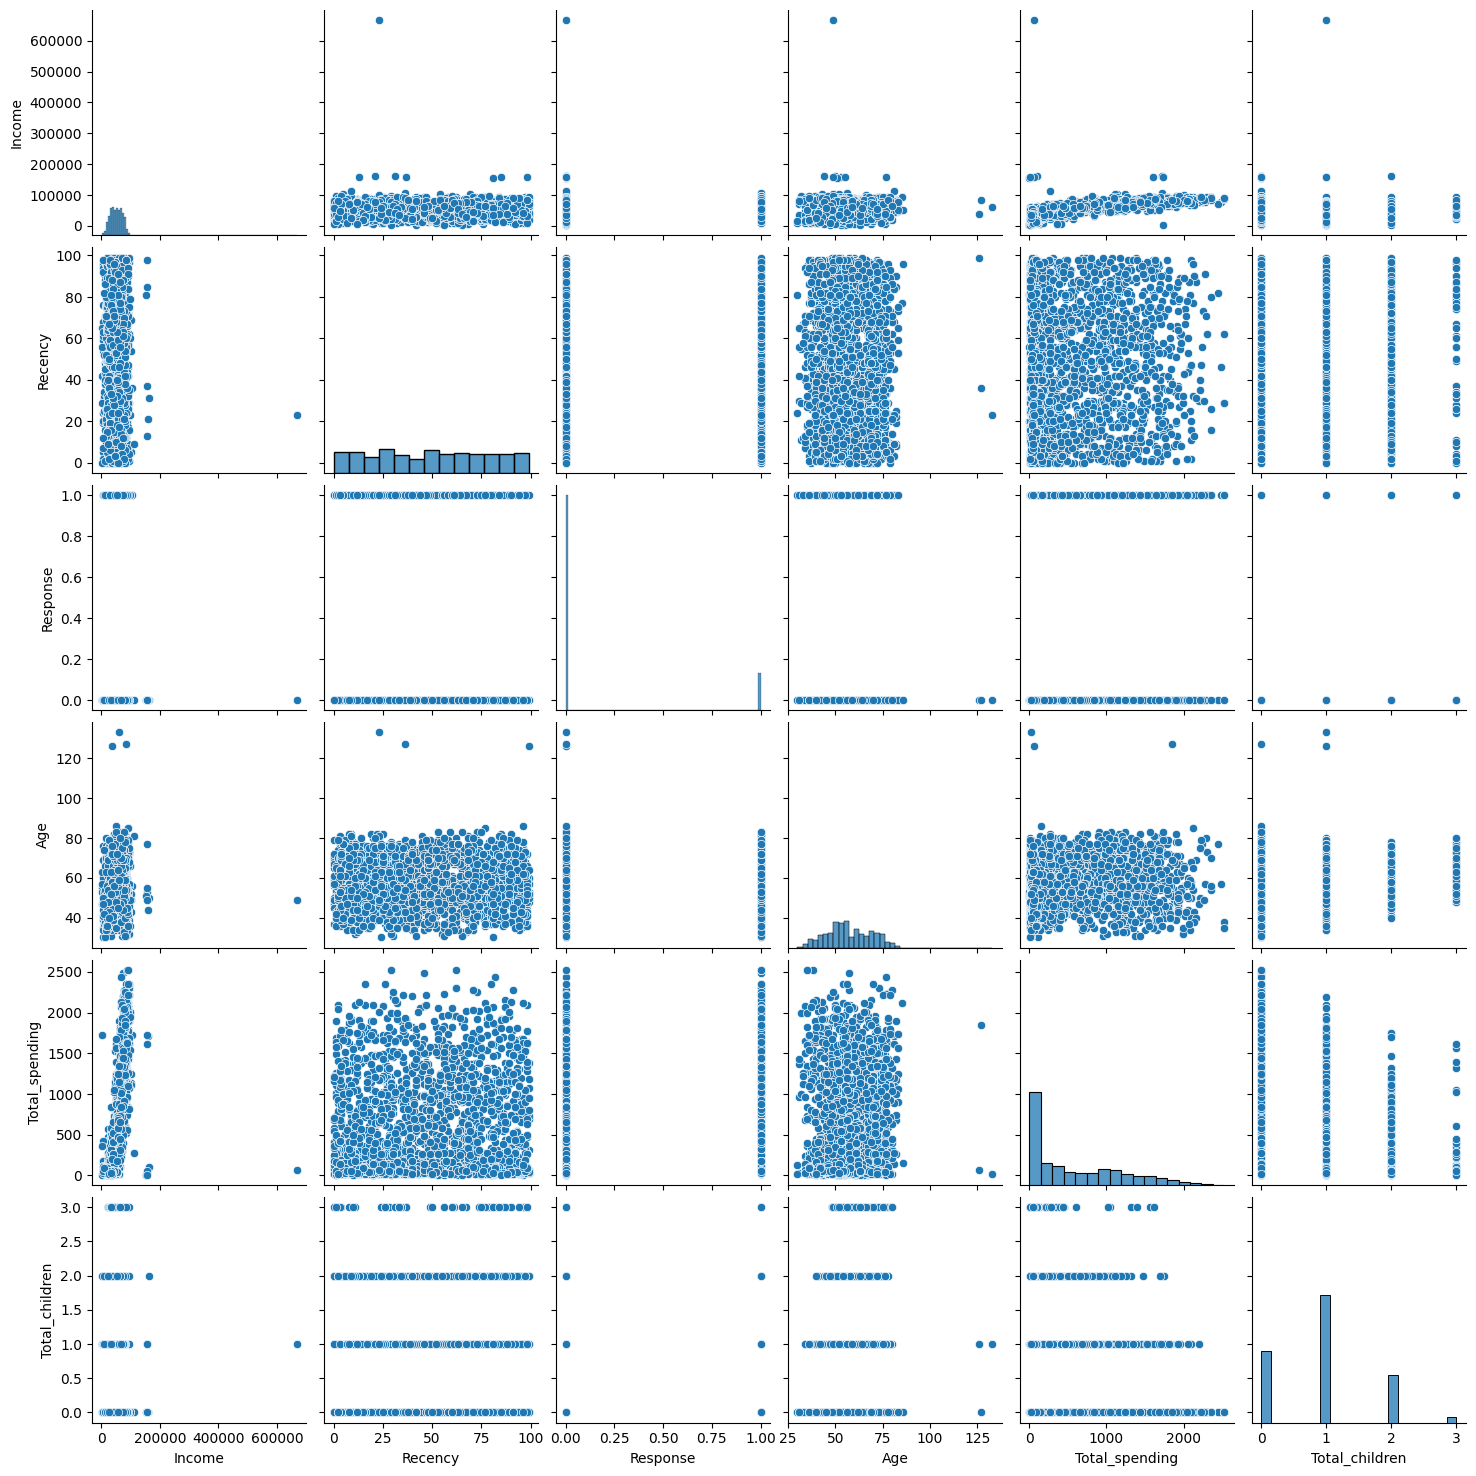

In [105]:
cols = ["Income","Recency","Response","Age","Total_spending","Total_children"]
# relative plots of some features- pair plots
sns.pairplot(df_cleaned[cols])

In [106]:
# Remove outliers

print("data size with outliers:",len(df_cleaned))

df_cleaned = df_cleaned[(df_cleaned["Age"]<90)]
df_cleaned = df_cleaned[(df_cleaned["Income"]<600_000)]
print("data size without outliers:",len(df_cleaned))

data size with outliers: 2240
data size without outliers: 2236


# Heatmap

In [107]:
corr= df_cleaned.corr(numeric_only = True)

<Axes: >

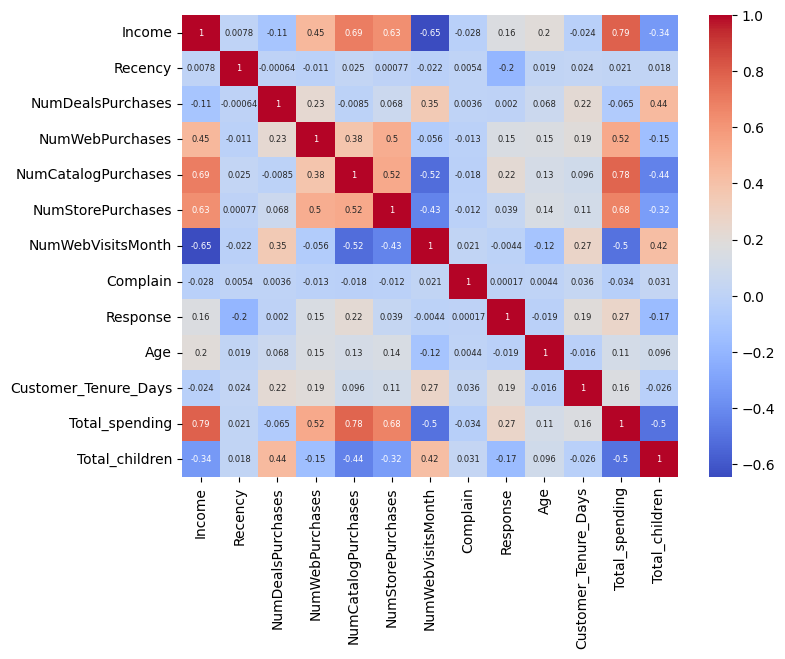

In [108]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot= True,
    annot_kws ={"size":6},
    
    cmap="coolwarm"
    
)

In [109]:
df_cleaned.shape

(2236, 15)

# Encoding

In [110]:
from sklearn.preprocessing import OneHotEncoder

In [111]:
ohe =  OneHotEncoder()
cat_cols = ["Education","Living_with"]
enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [112]:
enc_df=pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=df_cleaned.index)

In [113]:
enc_df.shape

(2236, 5)

In [114]:
df_encoded=pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis = 1)

In [115]:
df_encoded.shape

(2236, 18)

# Scaling

In [116]:
from sklearn.preprocessing import StandardScaler

In [117]:
X=df_encoded

In [118]:
scaler=StandardScaler()
x_scaled = scaler.fit_transform(X)

# Visualize

In [119]:
x_scaled.shape

(2236, 18)

In [120]:
# 2D
from sklearn.decomposition import PCA


In [133]:
pca = PCA (n_components = 3)
x_pca = pca.fit_transform(x_scaled)

In [134]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3d projection')

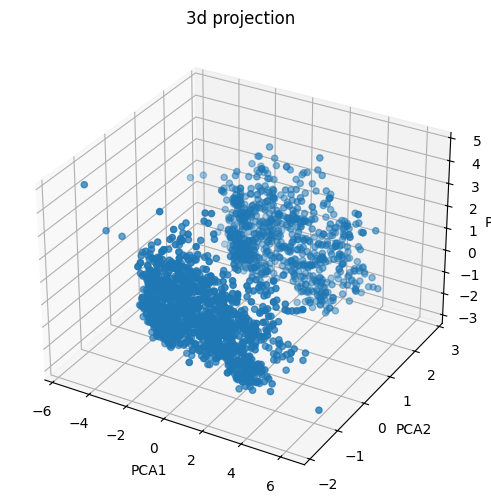

In [135]:
#plot
fig = plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

# Analyze K value

## 1. Elbow Method

In [138]:
from sklearn.cluster import  KMeans
from kneed import KneeLocator

wcss = []
for k in range(1,11):
    kmean =  KMeans(n_clusters=k,random_state = 42)
    kmean.fit_predict(x_pca)
    wcss.append(kmean.inertia_)

In [139]:
knee=KneeLocator(range(1,11), wcss,curve="convex",direction = "decreasing")
optimal_k = knee.elbow

In [141]:
print("best k=",optimal_k)

best k= 4


Text(0, 0.5, 'wcss')

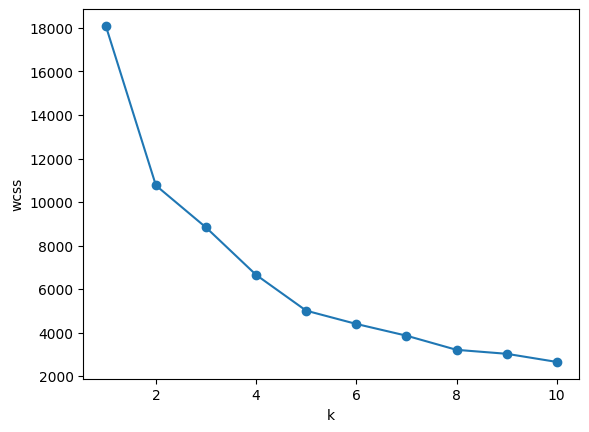

In [144]:
#plot

plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("k")
plt.ylabel("wcss")

## Silhouette Score

Text(0, 0.5, 'Silhouette_score')

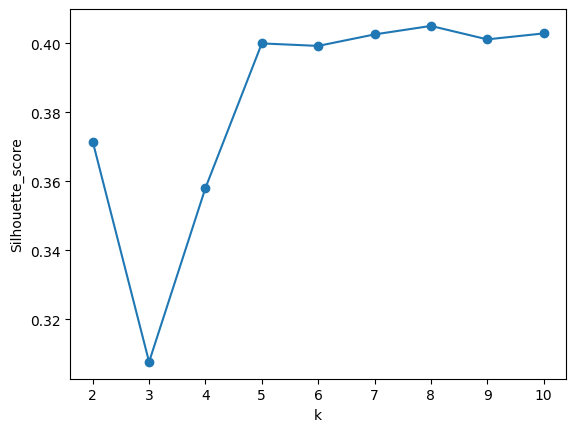

In [147]:
from sklearn.metrics import silhouette_score

scores = []
for k in range(2,11):
    kmeans = KMeans(n_clusters = k , random_state = 42)
    labels=kmeans.fit_predict(x_pca)
    score = silhouette_score(x_pca , labels)
    scores.append(score)



#plot

plt.plot(range(2,11),scores,marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette_score")

Text(0, 0.5, 'ss')

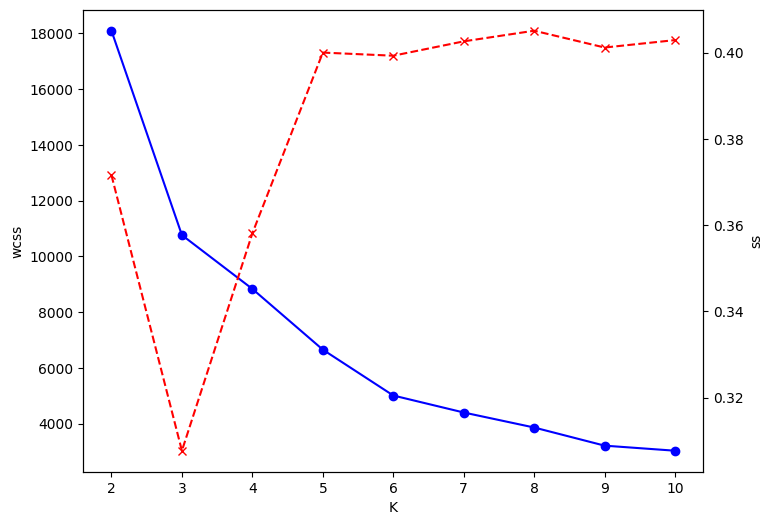

In [151]:
# combined plot

k_range = range(2,11)

fig ,ax1 = plt.subplots(figsize= (8,6))
ax1.plot(k_range , wcss[: len(k_range)],marker ="o",color = "blue")
ax1.set_xlabel("K")
ax1.set_ylabel("wcss")

ax2 = ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker="x",color="red",linestyle ="--")

ax2.set_ylabel("ss")


# Clustering

In [152]:
# K_means

kmeans = KMeans(n_clusters = 4 , random_state = 42)
labels_kmeans = kmeans.fit_predict(x_pca) 

Text(0.5, 0.92, '3d projection')

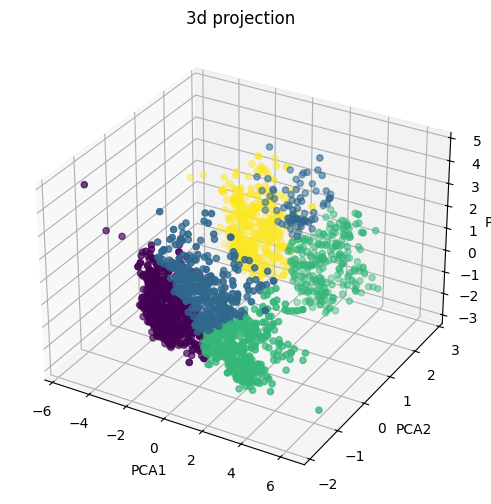

In [153]:
fig = plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2] ,c= labels_kmeans )
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

In [154]:
# Agglomerative clustering

from sklearn.cluster  import  AgglomerativeClustering


In [155]:
agg_clf = AgglomerativeClustering(n_clusters = 4,linkage="ward")
labels_agg=agg_clf.fit_predict(x_pca)


Text(0.5, 0.92, '3d projection')

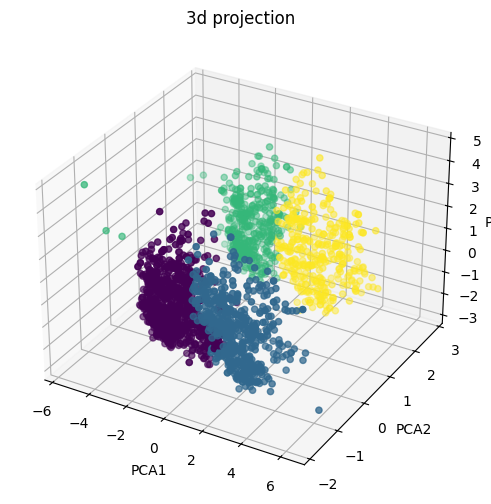

In [156]:
fig = plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(x_pca[:,0],x_pca[:,1],x_pca[:,2] ,c= labels_agg )
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

# Characterization of Clusters

In [168]:

X["cluster"] = labels_agg

In [169]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_with_Alone,Living_with_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

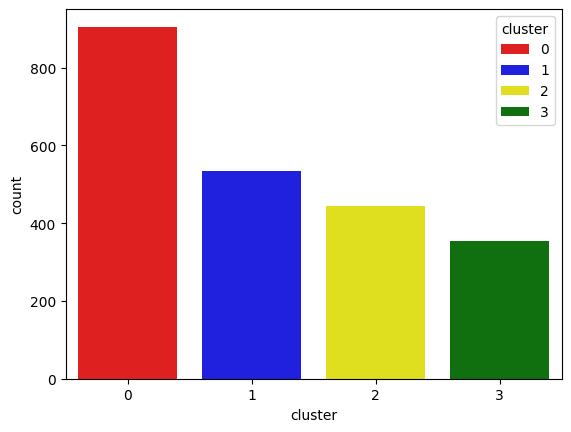

In [170]:
pal = ["red","blue","yellow","green"]

sns.countplot(x=X["cluster"],palette=pal,hue=df_cleaned["cluster"])

<Axes: xlabel='Total_spending', ylabel='Income'>

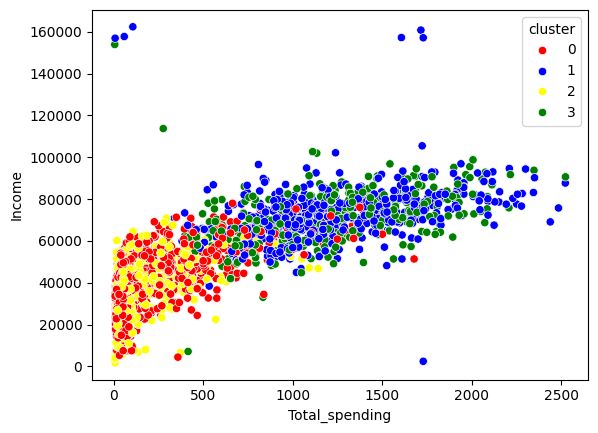

In [171]:
# INcome & spending patterns

sns.scatterplot(x=X["Total_spending"] , y=X["Income"],hue = X["cluster"],palette= pal)

In [173]:
# Cluster Summery

cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_Tenure_Days  Total_spending  \
cluster         